# Validación modelos

Aprender los parámetros de una función de predicción y probarla sobre los mismos datos es un error metodológico: un modelo que se limitara a repetir las etiquetas de las muestras que acaba de ver tendría una puntuación perfecta, pero no lograría predecir nada útil sobre datos aún no vistos. Esta situación se denomina sobreajuste. Para evitarla, cuando se realiza un experimento (supervisado) de aprendizaje automático, es habitual reservar una parte de los datos disponibles como conjunto de prueba X_prueba, y_prueba. Tenga en cuenta que la palabra "experimento" no se refiere únicamente a un uso académico, ya que incluso en entornos comerciales el aprendizaje automático suele comenzar de forma experimental. A continuación se muestra un diagrama de flujo del flujo de trabajo típico de validación cruzada en el entrenamiento de modelos. Los mejores parámetros pueden determinarse mediante técnicas de búsqueda en malla(grid).

Ya vimos que  scikit-learn se puede calcular rápidamente una partición aleatoria en conjuntos de entrenamiento y prueba con la función train_test_split. 
Sin embargo, al dividir los datos disponibles en tres conjuntos, reducimos drásticamente el número de muestras que pueden utilizarse para el aprendizaje del modelo, y los resultados pueden depender de una elección aleatoria concreta para el par de conjuntos (entrenamiento, validación).

Una solución a este problema es un procedimiento denominado validación cruzada (CV, por sus siglas en inglés). El conjunto de prueba debe seguir utilizándose para la evaluación final, pero el conjunto de validación ya no es necesario cuando se realiza la CV. En el enfoque básico, denominado CV k-fold, el conjunto de entrenamiento se divide en k conjuntos más pequeños (más adelante se describen otros enfoques, pero en general siguen los mismos principios). Se sigue el siguiente procedimiento para cada uno de los k "pliegues":

   *   Se entrena un modelo utilizando $k-1$ de los pliegues como datos de entrenamiento;

   *   El modelo resultalte se valida con la parte restante de los datos (es decir, se utiliza como conjunto de prueba para calcular una medida de rendimiento como la precisión).


`Scikit Learn` es la biblioteca de Python favorita para realizar muchas operaciones de aprendizaje automático y trae muchos métodos que ayudan a dividir los datos en un conjunto de entrenamiento, prueba y validación. Los más populares que revisaremos en este tutorial son:

* train_test_split: crea una división única en un conjunto de prueba y tren.
* Kfold: crea divisiones de k-fold que permiten la validación cruzada
* StratifiedKFold: crea divisiones de k-fold teniendo en cuenta la distribución de la variable de destino
* cross_val_score - puntuación del modelo evaluta a través de la validación cruzada

Veamos algunos casos de uso reales. En primer lugar, dividiremos un simple **rango de 25 números** y, a continuación, analizaremos el popular **conjunto de datos Iris**, que utiliza las medidas de los pétalos y los sépalos para predecir de qué tipo de flor Iris se trata. 

In [11]:
# Import scikit-learn libraries
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, cross_validate, cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# import libraries for charting and manipulations with datasets
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random

In [12]:
rn = np.linspace(0,25,26)

In [13]:
rn

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.])

In [14]:
kf5 = KFold(n_splits=5, shuffle=False)
kf3 = KFold(n_splits=3, shuffle=False)

In [15]:
for train_index, test_index in kf3.split(rn):
    print(train_index, test_index)

[ 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25] [0 1 2 3 4 5 6 7 8]
[ 0  1  2  3  4  5  6  7  8 18 19 20 21 22 23 24 25] [ 9 10 11 12 13 14 15 16 17]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17] [18 19 20 21 22 23 24 25]


In [16]:
for train_index, test_index in kf5.split(rn):
    print(train_index, test_index)

[ 6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25] [0 1 2 3 4 5]
[ 0  1  2  3  4  5 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25] [ 6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10 16 17 18 19 20 21 22 23 24 25] [11 12 13 14 15]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 21 22 23 24 25] [16 17 18 19 20]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20] [21 22 23 24 25]


# Graficamos la validación cruzada

Vamos a dividir nuestro rango de prueba en 5 y3 particiones y mostrar las divisiones en el gráfico. Para mostrar claramente qué datos pertenecen a cada conjunto, desplazaremos los valores en -.1 y +.1
La primera particion contendrá los valores 0.9 en el conjunto de entrenamiento y 1.1 en el conjunto de prueba, el segundo 1.9 y 2.1, etc. también daremos a cada conjunto el color diferente


In [17]:
def kfoldize(kf, rn, shift=.1):
    train = pd.DataFrame()
    test = pd.DataFrame()
    i = 1
    for train_index, test_index in kf.split(rn):
        train_df = pd.DataFrame(np.take(rn, train_index), columns=["x"])
        train_df["val"] = i - shift
        train= pd.concat([train, train_df]) 

        test_df = pd.DataFrame(np.take(rn, test_index), columns=["x"])
        test_df["val"] = i + shift
        test = pd.concat([test, test_df]) 
        i += 1
    return train, test

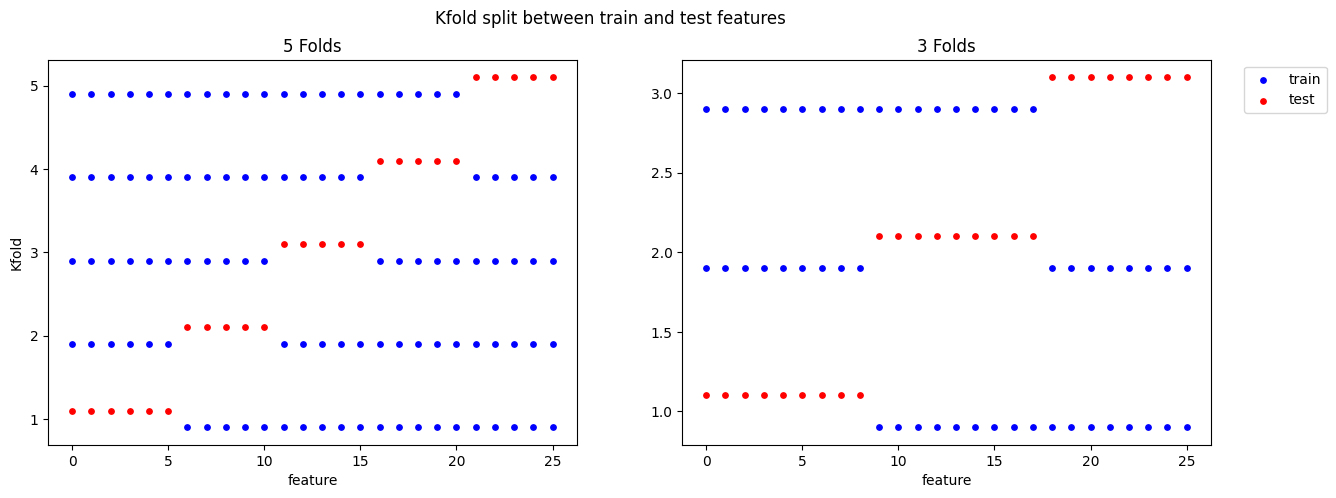

In [18]:
train5, test5 = kfoldize(kf5,rn)
train3, test3 = kfoldize(kf3,rn)

fig,ax = plt.subplots(1,2, figsize=(15,5))
ax[0].scatter(x="x",y="val",c="b",label="train",s=15,data=train5)
ax[0].scatter(x="x",y="val",c="r",label="test",s=15,data=test5)
ax[1].scatter(x="x",y="val",c="b",label="train",s=15,data=train3)
ax[1].scatter(x="x",y="val",c="r",label="test",s=15,data=test3)
ax[0].set_ylabel("Kfold")
ax[0].set_xlabel("feature")
ax[1].set_xlabel("feature")
ax[0].set_title("5 Folds")
ax[1].set_title("3 Folds")
plt.suptitle("Kfold split between train and test features")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

# Verificación de cómo se distribuyen los valores entre los conjuntos

In [19]:
def kfold_stats(df, name):
    s =  pd.Series({"Valor mínimo: ": df["x"].min(),
              "Valor máximo: ": df["x"].max(),
              "Oucrrencia minima: ": df["x"].value_counts().min(),
              "Ocurrencia maxima: ": df["x"].value_counts().max(),
               "Longitud mínima": df.groupby("val").count().min().values[0],
               "Longitud máxima": df.groupby("val").count().max().values[0]})
    s.name = name
    return s


In [20]:
pd.concat([kfold_stats(train5, "Train5"), kfold_stats(test5,"Test5"),
          kfold_stats(train3, "Train3"), kfold_stats(test3,"Test3")], 
          axis=1)

,Train5,Test5,Train3,Test3
Valor mínimo:,0.0,0.0,0.0,0.0
Valor máximo:,25.0,25.0,25.0,25.0
Oucrrencia minima:,4.0,1.0,2.0,1.0
Ocurrencia maxima:,4.0,1.0,2.0,1.0
Longitud mínima,20.0,5.0,17.0,8.0
Longitud máxima,21.0,6.0,18.0,9.0


La tabla anterior resume algunos datos clave sobre KFold:

* Valor mínimo y máximo: tanto el conjunto de entrenamiento como el de prueba cubren todas las características.
* Cada valor aparece una vez en el conjunto de prueba y k-1 veces en el conjunto de entrenamiento.
* Longitud mínima y máxima del valor: en caso de que el número de características no sea divisible por n, algunas se dividirán de forma diferente entre los conjuntos de prueba y de entrenamiento. Por ejemplo, en el caso de 25 características y 3 divisiones, las proporciones serán 16/9, 17/8, 17/8.

## KFold shuffled

En el ejemplo anterior, se ha visto la distribución tren/prueba no barajada. Dicha distribución puede influir en el resultado del modelo de aprendizaje automático, por lo que a menudo es útil dividir las características aleatoriamente para probar las capacidades de su modelo. Una división aleatoria de los datos se consigue mediante el parámetro `shuffle`. El parámetro `random-state` inicia el aleatorizador de forma que usando el mismo estado aleatorio se asegura la misma división. 

In [21]:
kf42 = KFold(n_splits=5, shuffle=True, random_state=42)
kf123 = KFold(n_splits=5, shuffle=True, random_state=123)

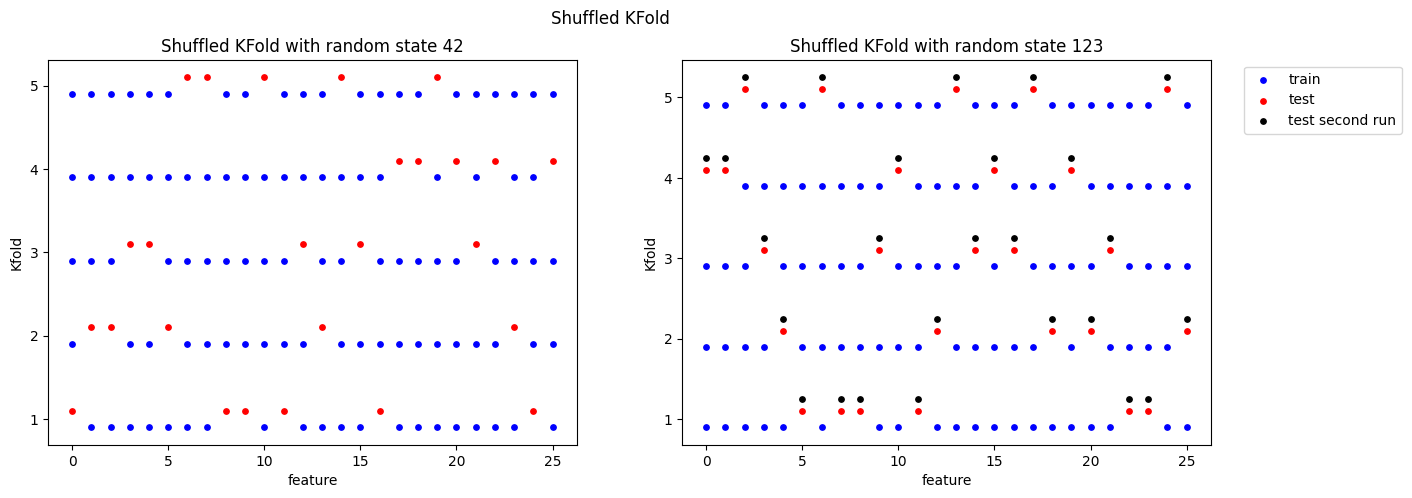

In [22]:
train42, test42 = kfoldize(kf42,rn)
train123, test123 = kfoldize(kf123,rn)
train123_2, test123_2 = kfoldize(kf123,rn,shift=.25)

fig,ax = plt.subplots(1,2, figsize=(15,5))
ax[0].scatter(x="x",y="val",c="b",label="train",s=15,data=train42) 
ax[0].scatter(x="x",y="val",c="r",label="test",s=15,data=test42)
ax[1].scatter(x="x",y="val",c="b",label="train",s=15,data=train123)
ax[1].scatter(x="x",y="val",c="r",label="test",s=15,data=test123)
ax[1].scatter(x="x",y="val",c="k",label="test second run",s=15,data=test123_2)
ax[0].set_ylabel("Kfold")
ax[0].set_xlabel("feature")
ax[0].set_title("Shuffled KFold with random state 42")
ax[1].set_ylabel("Kfold")
ax[1].set_xlabel("feature")
ax[1].set_title("Shuffled KFold with random state 123")
plt.suptitle("Shuffled KFold")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

# Kfold en el conjunto de datos real
Utilicemos el Kfold para evaluar un modelo de clasificación en el popular conjunto de datos Iris. Contiene 150 medidas de tamaños de pétalos y sépalos de las 3 variedades de la flor de Iris: setosa, versicolor y virginica. Cada uno contiene 50 medidas en el conjunto. 



In [23]:
iris = load_iris(return_X_y=False)
iris_df = pd.DataFrame(data=iris.data,columns=iris.feature_names)
features = iris['feature_names']
iris_df['target'] = iris.target
iris_df["target_name"] = iris_df['target'].map({i:name for i,name in enumerate(iris.target_names)})
iris_df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
69,5.6,2.5,3.9,1.1,1,versicolor
148,6.2,3.4,5.4,2.3,2,virginica
38,4.4,3.0,1.3,0.2,0,setosa
80,5.5,2.4,3.8,1.1,1,versicolor
5,5.4,3.9,1.7,0.4,0,setosa


In [24]:
pd.DataFrame(iris_df.groupby("target_name").size().reset_index()).rename(columns={0:"samples"})

,target_name,samples
0,setosa,50
1,versicolor,50
2,virginica,50


### Train test
Realicemos la regresión logística utilizando el método tradicional train_test_split, que dividirá los datos en un conjunto de entrenamiento y otro de prueba, de forma que cada valor objetivo aparezca un número similar de veces en el conjunto de entrenamiento y en el de prueba.

In [25]:
X = iris_df[features]
y = iris_df["target"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [26]:
model = LogisticRegression(solver="liblinear", multi_class="auto")

In [27]:
model.fit(X_train, y_train) #Training the model
pd.DataFrame({"Accurancy on Train":[accuracy_score(y_train, model.predict(X_train))],
    "Accurancy on Test":[accuracy_score(y_test, model.predict(X_test))]})

,Accurancy on Train,Accurancy on Test
0,0.958333,1.0


### KFold
El método Kfold devuelve el orden de las muestras elegidas para los conjuntos de entrenamiento y test en cada pliegue. En un marco de datos pandas tenemos que usar la función .iloc para obtener las filas correctas. Como no he dividido los datos en X (características) e y (objetivo) tengo que usar también .loc, para elegir las columnas correctas (.loc[:,características]) o simplemente elegir las columnas (['objetivo'])

In [28]:
kf3 = KFold(n_splits=3, shuffle=False)

In [29]:
i = 1
for train_index, test_index in kf3.split(iris_df):
    X_train = iris_df.iloc[train_index].loc[:, features]
    X_test = iris_df.iloc[test_index][features]
    y_train = iris_df.iloc[train_index].loc[:,'target']
    y_test = iris_df.loc[test_index]['target']
        
    #Train the model
    model.fit(X_train, y_train) #Training the model
    print(f"Accuracy for the fold no. {i} on the test set: {accuracy_score(y_test, model.predict(X_test))}")
    i += 1

Accuracy for the fold no. 1 on the test set: 0.0
Accuracy for the fold no. 2 on the test set: 0.0
Accuracy for the fold no. 3 on the test set: 0.0


In [30]:
iris_df.head(30)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


Pero, ¿por qué la precisión de cada pliegue es 0,0? La razón es la uniformidad de las divisiones. Dado que los datos están ordenados de forma que setosa aparece en las primeras cincuenta filas del conjunto de datos, seguida de versicolor y virginica, hemos conseguido una distribución única del conjunto de entrenamiento, que no contiene ningún objetivo esperado en el conjunto de prueba. La mayoría de los modelos de aprendizaje automático no pueden aprender a clasificar en una clase que nunca han visto. Lo que es visible en la tercera división

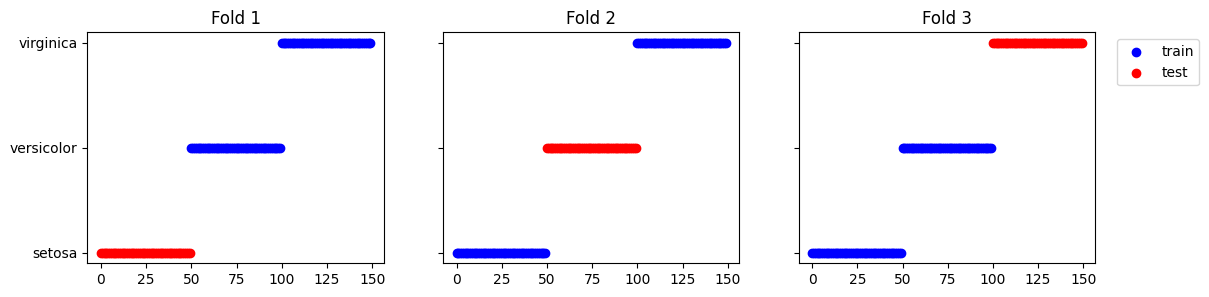

In [31]:
target_name = iris_df["target"]

fig, ax = plt.subplots(1,3, figsize=(13,3), sharey=True)
for i, (train_index, test_index) in enumerate(kf3.split(iris_df)):
    ax[i].scatter(x=train_index,y=target_name.iloc[train_index],label ="train", c='b')
    ax[i].scatter(x=test_index,y=target_name.iloc[test_index], label = "test", c='r')
    ax[i].set_title(f"Fold {i+1}")

ax[0].set_yticks([0,1,2])
ax[0].set_yticklabels(iris["target_names"])
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [32]:
iris_df=iris_df[:120]

# KFold barajado
Una forma de evitar este problema es utilizar el Kfold barajado



In [33]:
dfs = []
kf = KFold(n_splits=3, shuffle=True, random_state=123)
i = 1

for train_index, test_index in kf.split(iris_df):
    X_train = iris_df.iloc[train_index].loc[:, features]
    X_test = iris_df.iloc[test_index].loc[:,features]
    y_train = iris_df.iloc[train_index].loc[:,'target']
    y_test = iris_df.loc[test_index].loc[:,'target']
    
    #Train the model
    model.fit(X_train, y_train) #Training the model
    y_pred = model.predict(X_test)
    print(f"Accuracy for the fold no. {i} on the test set: {accuracy_score(y_test, y_pred)}")
    
    # how many occurances appear in the train set
    s_train = iris_df.iloc[train_index].loc[:,'target_name'].value_counts()
    s_train.name = f"train {i}"
    s_test = iris_df.iloc[test_index].loc[:,'target_name'].value_counts()
    s_test.name = f"test {i}"
    df = pd.concat([s_train, s_test], axis=1, sort=False)
    df["|"] = "|"
    dfs.append(df)
    
    i += 1

Accuracy for the fold no. 1 on the test set: 0.875
Accuracy for the fold no. 2 on the test set: 0.95
Accuracy for the fold no. 3 on the test set: 0.875


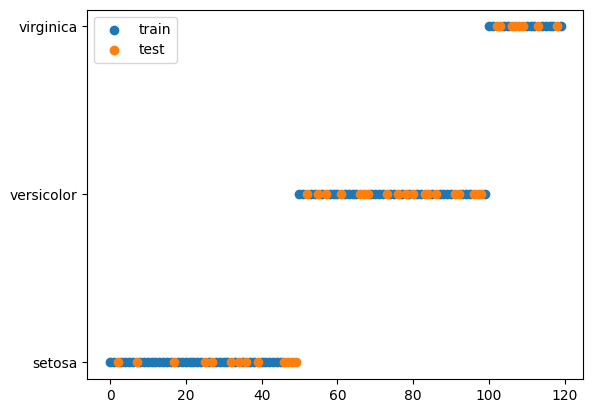

In [34]:
plt.scatter(x=y_train.index,y=iris_df.iloc[train_index].loc[:,'target_name'],label ="train")
plt.scatter(x=y_test.index,y=iris_df.iloc[test_index].loc[:,'target_name'], label = "test")
plt.legend()
plt.show()

In [35]:
pd.concat(dfs,axis=1, sort=False)

,train 1,test 1,|,train 2,test 2,|,train 3,test 3,|
target_name,,,,,,,,,
versicolor,34,16,|,35,15,|,31,19,|
setosa,32,18,|,31,19,|,37,13,|
virginica,14,6,|,14,6,|,12,8,|


## Stratified KFold
En lugar de utilizar Kfold aleatorio, podemos utilizar StratifiedKFold que necesita parámetro extra `y`. Como `y` se utiliza la variable objetivo para que el Kfold y recoger distribución equilibrada de los objetivos en cada partición.

In [36]:
dfs = []
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)
i = 1
for train_index, test_index in kf.split(iris_df, iris_df["target"]):
    X_train = iris_df.iloc[train_index].loc[:, features]
    X_test = iris_df.iloc[test_index].loc[:,features]
    y_train = iris_df.iloc[train_index].loc[:,'target']
    y_test = iris_df.loc[test_index].loc[:,'target']

    #Train the model
    model.fit(X_train, y_train) #Training the model
    print(f"Accuracy for the fold no. {i} on the test set: {accuracy_score(y_test, model.predict(X_test))}, doublecheck: {model.score(X_test,y_test)}")
    
    # how many occurances appear in the train set
    s_train = iris_df.iloc[train_index].loc[:,'target_name'].value_counts()
    s_train.name = f"train {i}"
    s_test = iris_df.iloc[test_index].loc[:,'target_name'].value_counts()
    s_test.name = f"test {i}"
    df = pd.concat([s_train, s_test], axis=1, sort=False)
    df["|"] = "|"
    dfs.append(df)
    
    i += 1

Accuracy for the fold no. 1 on the test set: 0.925, doublecheck: 0.925
Accuracy for the fold no. 2 on the test set: 0.875, doublecheck: 0.875
Accuracy for the fold no. 3 on the test set: 0.9, doublecheck: 0.9


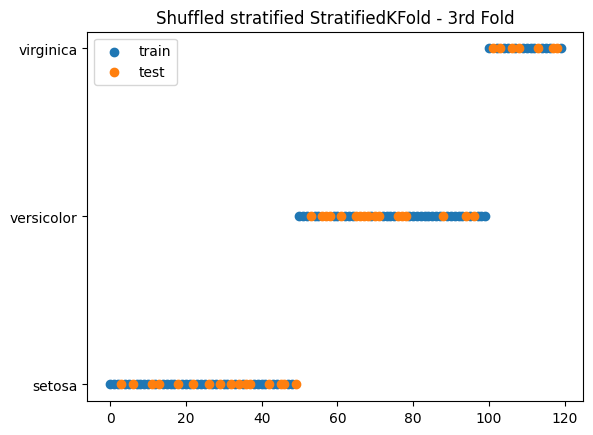

In [37]:
plt.scatter(x=y_train.index,y=iris_df.iloc[train_index].loc[:,'target_name'],label ="train")
plt.scatter(x=y_test.index,y=iris_df.iloc[test_index].loc[:,'target_name'], label = "test")
plt.legend()
plt.title("Shuffled stratified StratifiedKFold - 3rd Fold")
plt.show()

In [38]:
pd.concat(dfs,axis=1, sort=False)

,train 1,test 1,|,train 2,test 2,|,train 3,test 3,|
target_name,,,,,,,,,
setosa,33,17,|,33,17,|,34,16,|
versicolor,33,17,|,34,16,|,33,17,|
virginica,14,6,|,13,7,|,13,7,|


## Cross_validate 
cross_val_score entrenará usando tus datos y el número preferido de divisiones y te dará la puntuación en el conjunto de pruebas.


In [39]:
# cross_validate allow to specify metrics which you want to see
for i, score in enumerate(cross_validate(model, X,y, cv=3)["test_score"]):
    print(f"Accuracy for the fold no. {i} on the test set: {score}")

Accuracy for the fold no. 0 on the test set: 0.96
Accuracy for the fold no. 1 on the test set: 0.96
Accuracy for the fold no. 2 on the test set: 0.94


### Repeated KFold

In [40]:
from sklearn.model_selection import RepeatedKFold

kf42 = KFold(n_splits=3, shuffle=True, random_state=42)
krf42 = RepeatedKFold(n_splits=3, n_repeats=2, random_state=42)

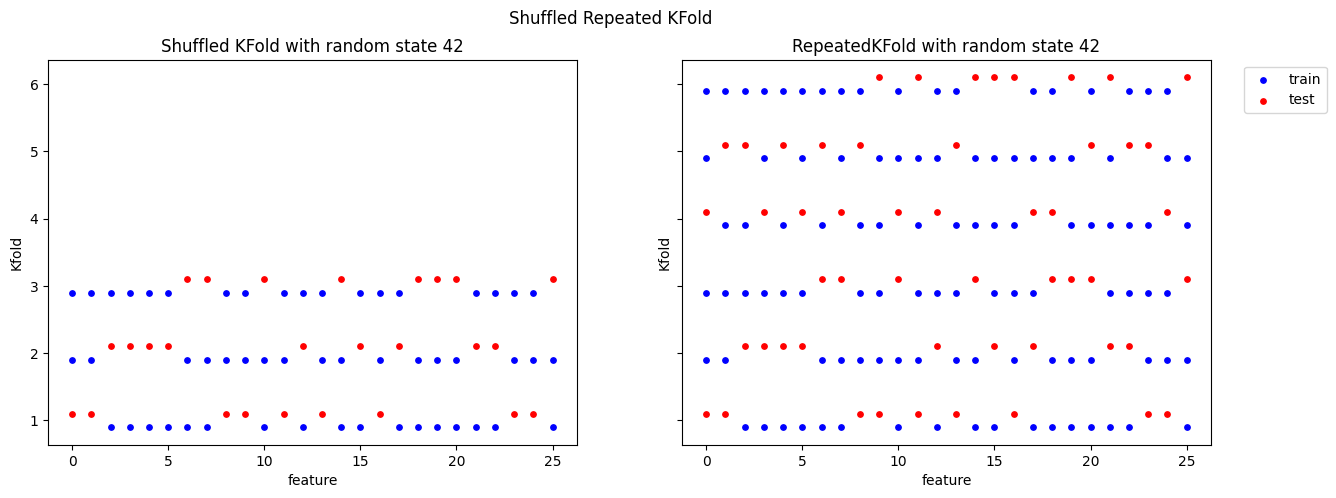

In [41]:
train42, test42 = kfoldize(kf42,rn)
train123, test123 = kfoldize(krf42,rn)
#train123_2, test123_2 = kfoldize(kf123,rn,shift=.25)

fig,ax = plt.subplots(1,2, figsize=(15,5), sharey=True)
ax[0].scatter(x="x",y="val",c="b",label="train",s=15,data=train42) 
ax[0].scatter(x="x",y="val",c="r",label="test",s=15,data=test42)
ax[1].scatter(x="x",y="val",c="b",label="train",s=15,data=train123)
ax[1].scatter(x="x",y="val",c="r",label="test",s=15,data=test123)
#ax[1].scatter(x="x",y="val",c="k",label="test second run",s=15,data=test123_2)
ax[0].set_ylabel("Kfold")
ax[0].set_xlabel("feature")
ax[0].set_title("Shuffled KFold with random state 42")
ax[1].set_ylabel("Kfold")
ax[1].set_xlabel("feature")
ax[1].set_title("RepeatedKFold with random state 42")
plt.suptitle("Shuffled Repeated KFold")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

El KFold repetido se baraja por diseño. La primera repetición es la misma que el KFold barajado con el mismo "estado aleatorio" y las siguientes repeticiones crean otra combinación de la división entrenamiento-prueba. 


### ShuffleSplit
https://scikit-learn.org/stable/modules/cross_validation.html#random-permutations-cross-validation-a-k-a-shuffle-split

In [42]:
from sklearn.model_selection import ShuffleSplit

kf42 = KFold(n_splits=3, shuffle=True, random_state=42)
ss = ShuffleSplit(n_splits=3, test_size=0.5, random_state=42)

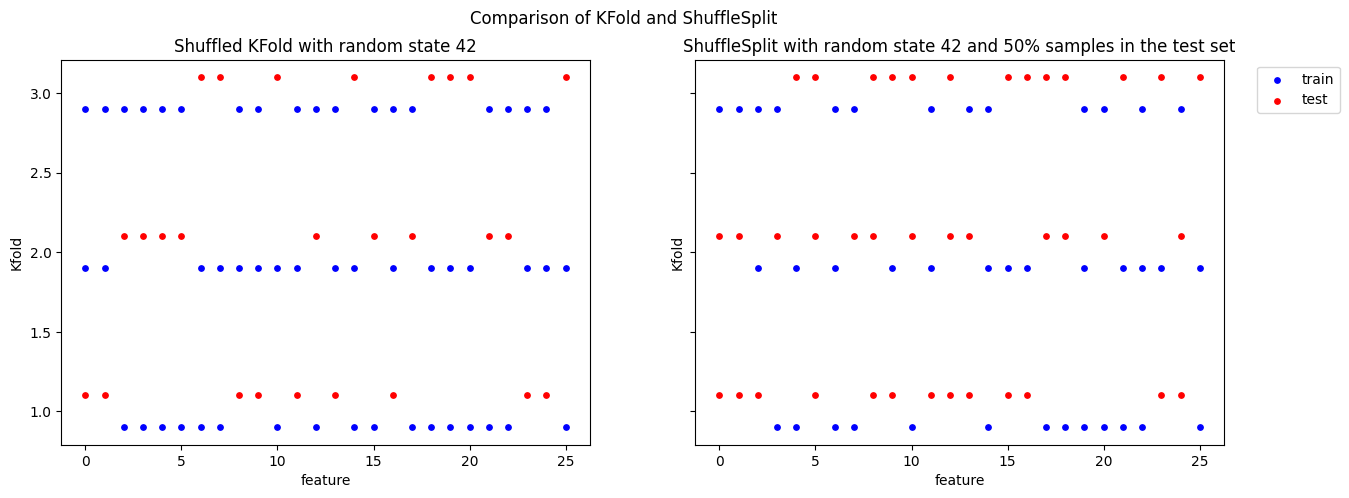

In [43]:
train42, test42 = kfoldize(kf42,rn)
train123, test123 = kfoldize(ss,rn)

fig,ax = plt.subplots(1,2, figsize=(15,5), sharey=True)
ax[0].scatter(x="x",y="val",c="b",label="train",s=15,data=train42) 
ax[0].scatter(x="x",y="val",c="r",label="test",s=15,data=test42)
ax[1].scatter(x="x",y="val",c="b",label="train",s=15,data=train123)
ax[1].scatter(x="x",y="val",c="r",label="test",s=15,data=test123)
ax[0].set_ylabel("Kfold")
ax[0].set_xlabel("feature")
ax[0].set_title("Shuffled KFold with random state 42")
ax[1].set_ylabel("Kfold")
ax[1].set_xlabel("feature")
ax[1].set_title("ShuffleSplit with random state 42 and 50% samples in the test set")
plt.suptitle("Comparison of KFold and ShuffleSplit")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

Mientras que KFold se asegura de que cada muestra aparezca una vez en el conjunto de prueba, con ShuffleSplit se especifica cuántas muestras hay en el conjunto de prueba. La división aleatoria estratificada tendría en cuenta la distribución de una variable etiquedada

### Leave One Out

In [44]:
from sklearn.model_selection import LeaveOneOut

kf42 = KFold(n_splits=3, shuffle=True, random_state=42)
loo = LeaveOneOut()

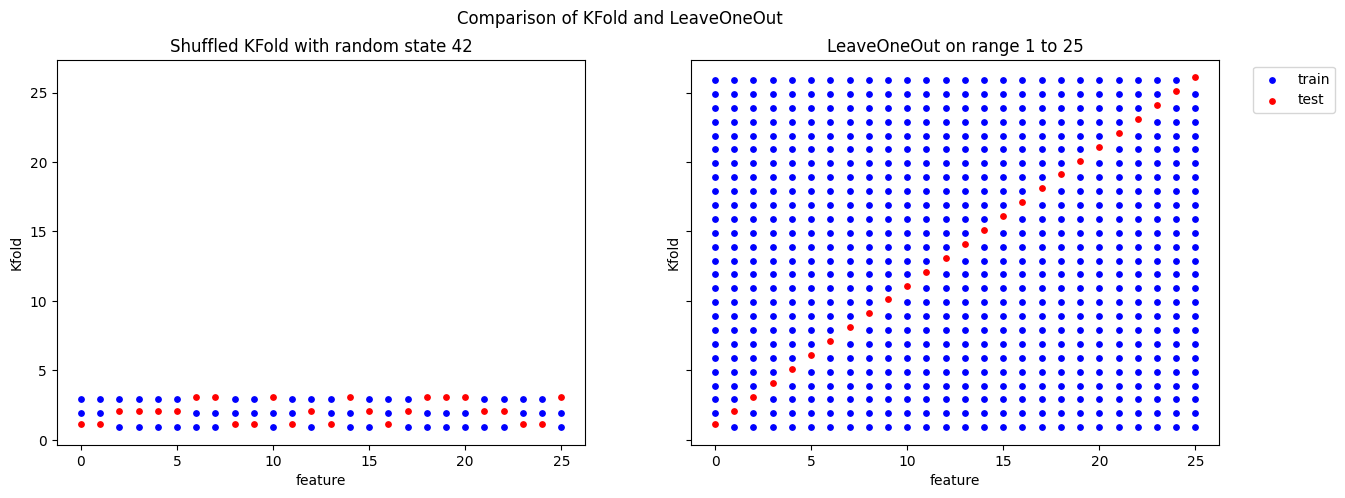

In [45]:
train42, test42 = kfoldize(kf42,rn)
train123, test123 = kfoldize(loo,rn)

fig,ax = plt.subplots(1,2, figsize=(15,5), sharey=True)
ax[0].scatter(x="x",y="val",c="b",label="train",s=15,data=train42) 
ax[0].scatter(x="x",y="val",c="r",label="test",s=15,data=test42)
ax[1].scatter(x="x",y="val",c="b",label="train",s=15,data=train123)
ax[1].scatter(x="x",y="val",c="r",label="test",s=15,data=test123)
#ax[1].scatter(x="x",y="val",c="k",label="test second run",s=15,data=test123_2)
ax[0].set_ylabel("Kfold")
ax[0].set_xlabel("feature")
ax[0].set_title("Shuffled KFold with random state 42")
ax[1].set_ylabel("Kfold")
ax[1].set_xlabel("feature")
ax[1].set_title("LeaveOneOut on range 1 to 25")
plt.suptitle("Comparison of KFold and LeaveOneOut")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

Leave One Out hace lo que dice, deja sólo una observación como muestra de prueba. 

La documentación de Scikit discute estos temas y sugiere: "Como regla general, la mayoría de los autores, y la evidencia empírica, sugieren que la validación cruzada de 5 o 10 pliegues debe preferirse a LOO".
Más información: https://scikit-learn.org/stable/modules/cross_validation.html#leave-one-out-loo

Leave P Out

https://scikit-learn.org/stable/modules/cross_validation.html#leave-p-out-lpo


In [46]:
from sklearn.model_selection import LeavePOut

kf42 = KFold(n_splits=3, shuffle=True, random_state=42)
lpo = LeavePOut(p=2)

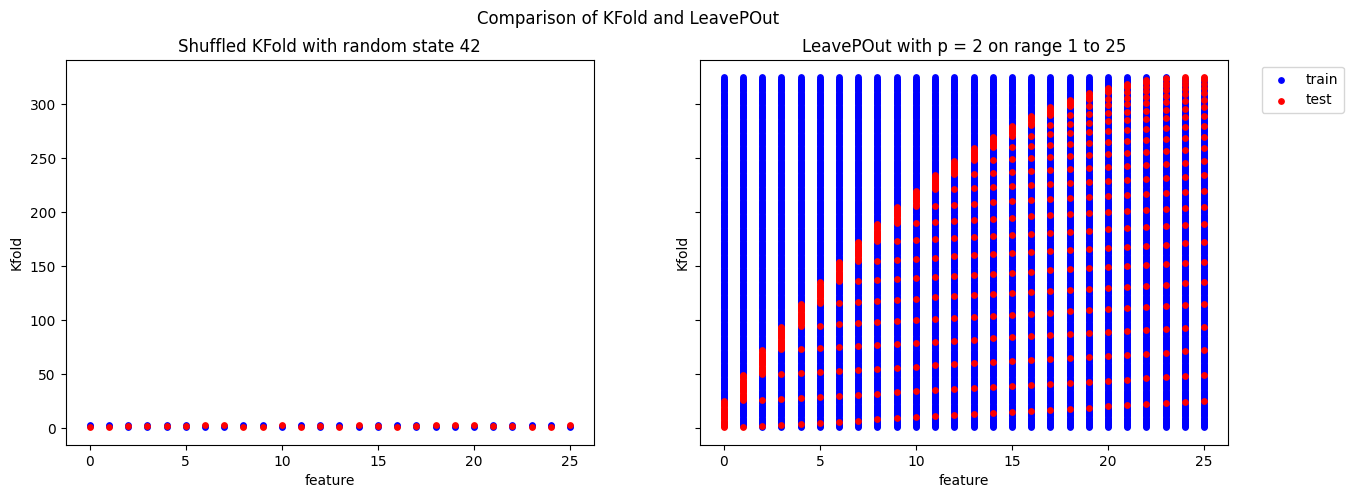

In [47]:
train42, test42 = kfoldize(kf42,rn)
train123, test123 = kfoldize(lpo,rn)

fig,ax = plt.subplots(1,2, figsize=(15,5), sharey=True)
ax[0].scatter(x="x",y="val",c="b",label="train",s=15,data=train42) 
ax[0].scatter(x="x",y="val",c="r",label="test",s=15,data=test42)
ax[1].scatter(x="x",y="val",c="b",label="train",s=15,data=train123)
ax[1].scatter(x="x",y="val",c="r",label="test",s=15,data=test123)
ax[0].set_ylabel("Kfold")
ax[0].set_xlabel("feature")
ax[0].set_title("Shuffled KFold with random state 42")
ax[1].set_ylabel("Kfold")
ax[1].set_xlabel("feature")
ax[1].set_title("LeavePOut with p = 2 on range 1 to 25")
plt.suptitle("Comparison of KFold and LeavePOut")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

Dejar P fuera crea ${n \choose p}$ combinación, por lo que en nuestro ejemplo ${25 \choose 2} = 300$ 


# Conclusión

Hemos revisado cómo funcionan los métodos Sklearn `Kfold`. Hemos visto que divide los datos en un número `n` de conjuntos. Cada una de las características aparecerá una vez en el conjunto de prueba y `n-1` veces en el conjunto de entrenamiento. También puede utilizar `ShuffleSplit` o `RepeatedKFold` si desea tener una distribución diferente de entrenamiento-prueba. 

En el KFold normal, cada pliegue contendrá `1/n` valores en el conjunto de entrenamiento y `n-1/n` valores en el conjunto de prueba. Así, para `n=2` el 50% estará en el conjunto de prueba, `n=3` el 33%, `n=4` el 25%, etc. 

Podemos dividir los datos en el orden en que aparecen utilizando `shuffle=False` o aleatoriamente con `shuffle=True` y opcionalmente indicando un `random_state`. Tener el mismo estado aleatorio siempre resultará en la misma división de los datos de prueba y de entrenamiento.

No es necesario dividir los datos manualmente y sólo se pueden aplicar los métodos `cross-validate` o `cross-val-score`. Los datos se dividirán en segundo plano y usted recibirá la puntuación final. 


## Series temporales
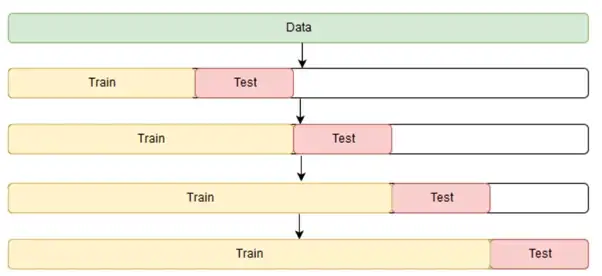

In [48]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
X = np.array([[1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4]])
y = np.array([1, 2, 3, 4, 5, 6])


In [49]:
tscv = TimeSeriesSplit()
print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [50]:

TimeSeriesSplit(max_train_size=None, n_splits=3)
for train_index, test_index in tscv.split(X):
    print("TRAIN:", train_index, "TEST:", test_index) 
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

TRAIN: [0] TEST: [1]
TRAIN: [0 1] TEST: [2]
TRAIN: [0 1 2] TEST: [3]
TRAIN: [0 1 2 3] TEST: [4]
TRAIN: [0 1 2 3 4] TEST: [5]


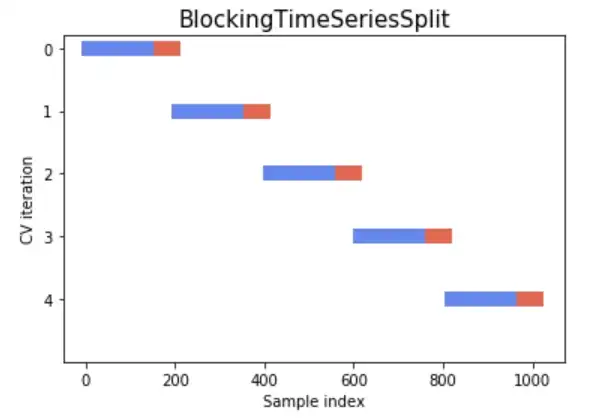

In [51]:
tp=TimeSeriesSplit(max_train_size=3,test_size=1)
for train_index, test_index in tp.split(X):
    print("TRAIN:", train_index, "TEST:", test_index) 
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

TRAIN: [0] TEST: [1]
TRAIN: [0 1] TEST: [2]
TRAIN: [0 1 2] TEST: [3]
TRAIN: [1 2 3] TEST: [4]
TRAIN: [2 3 4] TEST: [5]
